## WORKSHOP 2- Object detection using web camera
## 

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
weights_path = "yolov4.weights"
config_path = "yolov4.cfg"
names_path = "coco.names.txt"

net = cv2.dnn.readNet(weights_path, config_path)

with open(names_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

colors = np.random.uniform(0, 255, size=(len(classes), 3))

print("YOLOv4 Loaded Successfully")

YOLOv4 Loaded Successfully


In [11]:
def detect_objects(frame):

    height, width, channels = frame.shape

    blob = cv2.dnn.blobFromImage(
        frame,
        scalefactor=1/255.0,
        size=(416, 416),
        swapRB=True,
        crop=False
    )

    net.setInput(blob)
    outputs = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    for output in outputs:

        for detection in output:

            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            if confidence > 0.5:

                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)

                w = int(detection[2] * width)
                h = int(detection[3] * height)

                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    indexes = cv2.dnn.NMSBoxes(
        boxes,
        confidences,
        0.5,
        0.4
    )

    if len(indexes) > 0:

        for i in indexes.flatten():

            x, y, w, h = boxes[i]

            label = classes[class_ids[i]]
            confidence = confidences[i]

            color = colors[class_ids[i]]

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                color,
                2
            )

            cv2.putText(
                frame,
                f"{label} {confidence:.2f}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    return frame

In [12]:
cap = cv2.VideoCapture(0)

ret, captured_image = cap.read()

cap.release()

if ret:
    print("Image Captured Successfully")
else:
    print("Failed to Capture Image")

Image Captured Successfully


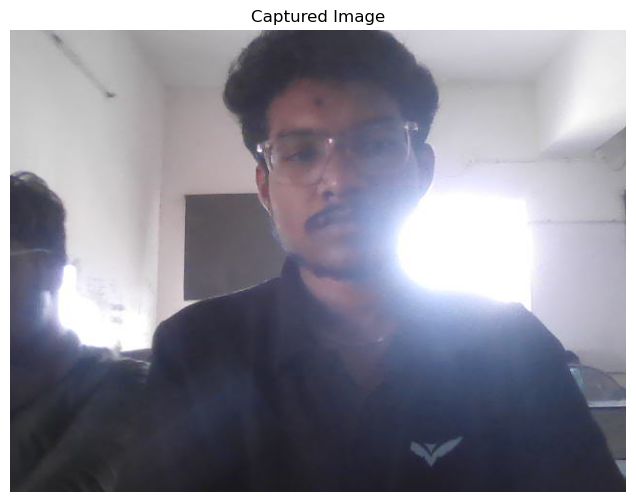

In [13]:
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(captured_image, cv2.COLOR_BGR2RGB))
plt.title("Captured Image")
plt.axis("off")
plt.show()

In [14]:
detected_image = detect_objects(captured_image)

print("Detection Completed")

Detection Completed


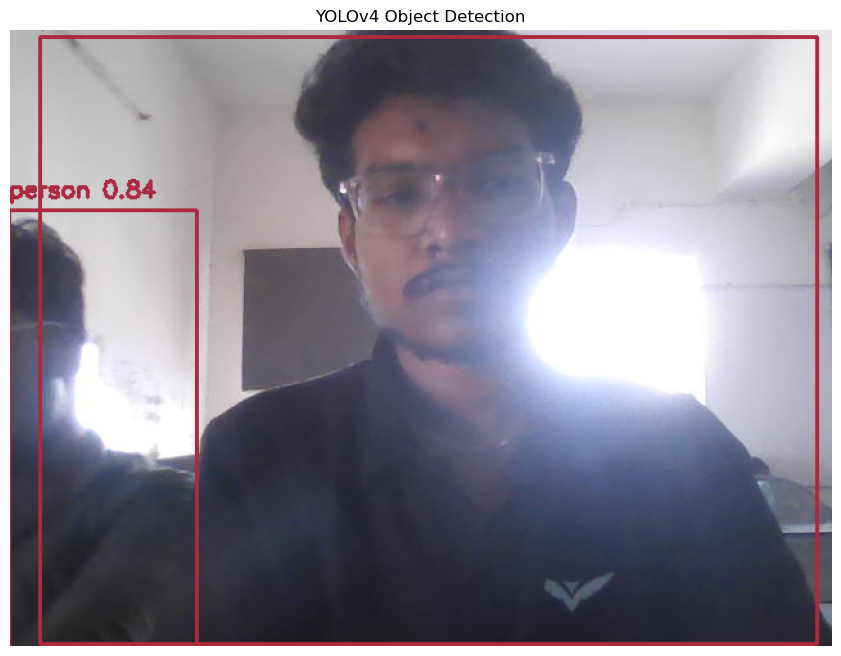

In [15]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
plt.title("YOLOv4 Object Detection")
plt.axis("off")
plt.show()

In [16]:
cv2.imwrite("detected_result.jpg", detected_image)

print("Result saved as detected_result.jpg")

Result saved as detected_result.jpg
